In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_dir = '/content/drive/MyDrive/NEU Metal Surface Defects Data'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

classes = ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled', 'Scratches']

print("Train samples per class:")
for cls in classes:
    print(f"  {cls}: {len(os.listdir(os.path.join(train_dir, cls)))}")

print("\nValid samples per class:")
for cls in classes:
    print(f"  {cls}: {len(os.listdir(os.path.join(valid_dir, cls)))}")

print("\nTest samples per class:")
for cls in classes:
    print(f"  {cls}: {len(os.listdir(os.path.join(test_dir, cls)))}")

Train samples per class:
  Crazing: 276
  Inclusion: 276
  Patches: 276
  Pitted: 285
  Rolled: 276
  Scratches: 276

Valid samples per class:
  Crazing: 12
  Inclusion: 12
  Patches: 12
  Pitted: 12
  Rolled: 12
  Scratches: 12

Test samples per class:
  Crazing: 12
  Inclusion: 12
  Patches: 12
  Pitted: 12
  Rolled: 12
  Scratches: 12


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Parameters (same as before)
IMG_SIZE = 224
BATCH_SIZE = 32  # Adjust to 16 if GPU memory is low
NUM_CLASSES = 6

# Data generators
# Train: With augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize to [0,1]
    rotation_range=20,      # Slight rotations (±20°)
    width_shift_range=0.2,  # Horizontal shifts
    height_shift_range=0.2, # Vertical shifts
    horizontal_flip=True,   # Mirror images (defects can appear flipped)
    zoom_range=0.2,         # Zoom in/out
    fill_mode='nearest'     # Fill empty pixels after transforms
)

# Valid/Test: No augmentation—just normalization for clean eval
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Paths (updated for your folders)
base_dir = '/content/drive/MyDrive/NEU Metal Surface Defects Data'  # Adjust if different
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')  # Change to 'val' if that's your folder name
test_dir = os.path.join(base_dir, 'test')

# Load generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # One-hot labels for multi-class
    color_mode='rgb'           # Duplicate grayscale to 3 channels for ResNet
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False  # Keep order for accurate eval
)

# Verify class mapping (should match your folder names)
print("Class indices:", train_generator.class_indices)
print(f"Found {train_generator.samples} train images across {NUM_CLASSES} classes")

Found 1665 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Class indices: {'Crazing': 0, 'Inclusion': 1, 'Patches': 2, 'Pitted': 3, 'Rolled': 4, 'Scratches': 5}
Found 1665 train images across 6 classes


In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load pre-trained ResNet-50 (no top layers)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze base layers initially
base_model.trainable = False

# Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduces spatial dims to 1x1
x = Dense(256, activation='relu')(x)  # Hidden layer for complexity
x = Dropout(0.5)(x)  # Regularization to prevent overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x)  # Output probs

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer='adam',  # Adaptive optimizer for fast convergence
    loss='categorical_crossentropy',  # For multi-class
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),  # Stop if no improvement
    ModelCheckpoint('/content/drive/MyDrive/NEU_dataset/best_model.h5', save_best_only=True),  # Save best
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

# Initial training (frozen base)
history = model.fit(
    train_generator,
    epochs=20,  # Start small; increase if needed
    validation_data=valid_generator,
    callbacks=callbacks
)

# Fine-tune: Unfreeze top layers
base_model.trainable = True
for layer in base_model.layers[:-20]:  # Freeze all but last 20 layers
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune
history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=valid_generator,
    callbacks=callbacks
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1575 - loss: 2.0900

53/53 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.1578 - loss: 2.0877 - val_accuracy: 0.1667 - val_loss: 1.7931 - learning_rate: 0.0010
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.1731 - loss: 1.8122

53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 547ms/step - accuracy: 0.1732 - loss: 1.8119 - val_accuracy: 0.1667 - val_loss: 1.7839 - learning_rate: 0.0010
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.1924 - loss: 1.7860

53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 541ms/step - accuracy: 0.1924 - loss: 1.7860 - val_accuracy: 0.1806 - val_loss: 1.7777 - learning_rate: 0.0010
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.2260 - loss: 1.7751

53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 537ms/step - accuracy: 0.2257 - loss: 1.7751 - val_accuracy: 0.2917 - val_loss: 1.7698 - learning_rate: 0.0010
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.2111 - loss: 1.7749

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 533ms/step - accuracy: 0.2707 - loss: 1.6222 - val_accuracy: 0.3750 - val_loss: 1.5932 - learning_rate: 0.0010
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 55s 693ms/step - accuracy: 0.2639 - loss: 1.9855 - val_accuracy: 0.1806 - val_loss: 1.7581 - learning_rate: 1.0000e-04
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 478ms/step - accuracy: 0.4427 - loss: 1.2972 - val_accuracy: 0.2917 - val_loss: 1.6228 - learning_rate: 1.0000e-04
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 25s 475ms/step - accuracy: 0.5616 - loss: 1.0988 - val_accuracy: 0.3056 - val_loss: 1.6814 - learning_rate: 1.0000e-04
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 489ms/step - accuracy: 0.6588 - loss: 0.8884 - val_accuracy: 0.3333 - val_loss: 1.5958 - learning_rate: 1.0000e-04
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.7413 - loss: 0.7456

53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 522ms/step - accuracy: 0.7412 - loss: 0.7456 - val_accuracy: 0.3611 - val_loss: 1.5017 - learning_rate: 1.0000e-04
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7398 - loss: 0.7004

53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 592ms/step - accuracy: 0.7400 - loss: 0.7000 - val_accuracy: 0.4583 - val_loss: 1.3515 - learning_rate: 1.0000e-04
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 585ms/step - accuracy: 0.6941 - loss: 0.8839 - val_accuracy: 0.4028 - val_loss: 3.5212 - learning_rate: 1.0000e-04
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.7678 - loss: 0.6962

53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 530ms/step - accuracy: 0.7677 - loss: 0.6956 - val_accuracy: 0.4028 - val_loss: 1.3129 - learning_rate: 1.0000e-04
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.8043 - loss: 0.5692

53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 610ms/step - accuracy: 0.8042 - loss: 0.5692 - val_accuracy: 0.7222 - val_loss: 0.8185 - learning_rate: 1.0000e-04
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 547ms/step - accuracy: 0.8222 - loss: 0.5350 - val_accuracy: 0.2361 - val_loss: 5.1458 - learning_rate: 1.0000e-04


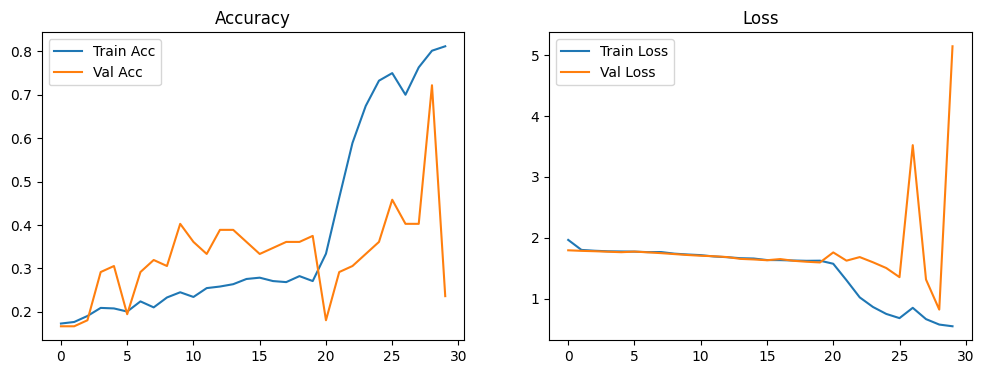

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'] + history_fine.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step
              precision    recall  f1-score   support

     Crazing       0.78      0.58      0.67        12
   Inclusion       0.67      0.83      0.74        12
     Patches       1.00      0.50      0.67        12
      Pitted       0.45      0.75      0.56        12
      Rolled       0.62      0.67      0.64        12
   Scratches       1.00      0.75      0.86        12

    accuracy                           0.68        72
   macro avg       0.75      0.68      0.69        72
weighted avg       0.75      0.68      0.69        72



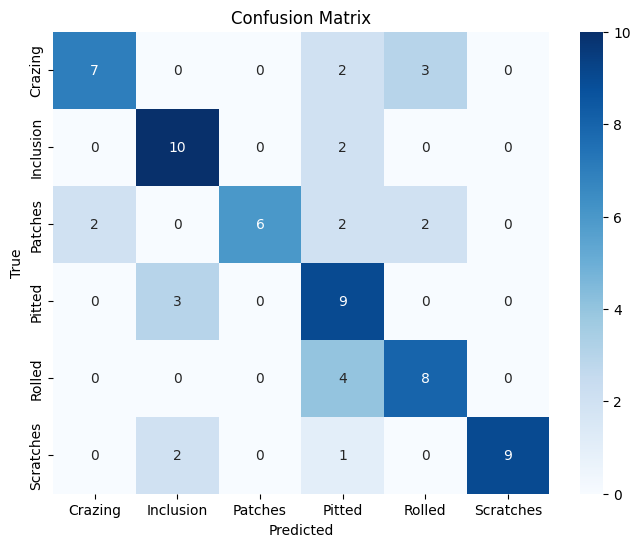

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions
test_preds = model.predict(test_generator)
test_labels = test_generator.classes
test_preds_classes = np.argmax(test_preds, axis=1)

# Metrics
print(classification_report(test_labels, test_preds_classes, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()